In [1]:
import modules.utils as u
u.Devices()._cuda_list_gpus()

[('cuda:2', 'NVIDIA A100-SXM4-80GB', 80285),
 ('cuda:1', 'NVIDIA A100-SXM4-80GB', 80141),
 ('cuda:0', 'NVIDIA A100-SXM4-80GB', 76353),
 ('cuda:3', 'NVIDIA A100-SXM4-80GB', 55294),
 ('cuda:6', 'NVIDIA A100-SXM4-80GB', 36206),
 ('cuda:5', 'NVIDIA A100-SXM4-80GB', 31049),
 ('cuda:4', 'NVIDIA A100-SXM4-80GB', 26439),
 ('cuda:7', 'NVIDIA A100-SXM4-80GB', 15431)]

In [2]:
#### mv packages ####
import modules.data as d
import modules.utils as u
from pathlib import Path

#### init ####
dataset_dir = Path('/home/mv18gs/Documents/GitHub/pathway_model/datasets/')
device, generator = u.Devices().auto_set_device(drop=['cuda:1','cuda:6'])

#### data ####
brca = d.TCGA(
    tcga_project = 'BRCA',
    tcga_dir = dataset_dir/'tcga',
    # type_col = 'sample_type',
    subtype_col = 'paper_BRCA_Subtype_PAM50',
    drop = ['Normal', 'Primary Tumor', 'Metastatic'],
    gene_name_path = dataset_dir/'other'/'name2ensg.csv',
    keep_noname = False,
)

kegg = d.KEGG(
    relation_filepath=dataset_dir/'other'/'relation_ohe.csv', 
    counts_data=brca,
)

data = d.Preprocessor(brca, kegg, kegg)
_dataset = d.GraphDataset(data)
_batch = d.get_toy_databatch(_dataset, generator)

# #### Device() ####
# device = cuda:2

# #### KEGG() ####
# relation                 (75939, 19)              DataFrame
# ensg                     4373                     list
# pathway_labels           305                      list
# edge_index               (2, 32464)               Tensor (cuda:2)
# edge_attr                (32464, 16)              Tensor (cuda:2)
# edge_labels              16                       list
# pathway_index            (4373, 305)              Tensor (cuda:2)

# #### TCGA() ####
# counts_path              PosixPath
# metadata_path            PosixPath
# gene_name_path           PosixPath
# metadata_complete        (1231, 93)               DataFrame
# metadata                 (1172, 2)                DataFrame
# y                        (1172,)                  Tensor (cuda:2)
# y_labels                 5                        list
# ensgv                    (60660, 3)               DataFrame
# ensg_complete            19213                    list
# cou

In [3]:
import modules.train as t
import modules.model2T as m
from modules.layersT import tAttentionSetPooling

import torch
import torch.nn as nn
from torch_geometric.nn import GCNConv, GATConv

loader = t.Loader(
    dataset=_dataset,
    generator=generator,
    batch_size=128
)

dm = t.DataloaderMean(loader.train_loader, data.num_nodes, data.num_node_features)
x_mean = dm.get_mean(4)

ae = m.Autoencoder(
    # dims
    data=data,
    head_dim=32,
    num_heads=10,
    
    # nb
    nb=True,
    x_mean=x_mean,

    # layers
    encoder_class=nn.Linear,
    pooling_class=tAttentionSetPooling,
    mlp=True,
    method='set',

    # layer params
    hidden_dims=[128,128,128], 
    act_fn=nn.ReLU, 
    norm_fn='layer', 
    end_fn=False,
)

trainer = t.NBReconTrainer(
    model=ae,
    
    loader=loader,
    num_epochs=30,
    loss_fn=nn.MSELoss(),
    optimizer_kwargs={'lr':5e-4},
    verbose=True,
    report_metrics=['loss','mae','rmse', 'r2'],
)

display(trainer.test_metrics)
# out = ae(_batch, need_weights=False)
# print(out.keys() if isinstance(out, dict) else out)
# print([k for k,v in out.items() if v is None])

100%|██████████| 30/30 [01:40<00:00,  3.35s/it, Epoch 29      Train: loss=10.6657    mae=0.7511    rmse=1.1176    r2=0.8435        Val: loss=10.7255    mae=0.7453    rmse=1.1180    r2=0.8427]


Test	 loss=10.6213    mae=0.7460    rmse=1.1114    r2=0.8449



{'loss': 10.621253967285156,
 'mean': -0.02848237194120884,
 'std': 1.1110397577285767,
 'mae': 0.7459954619407654,
 'mse': 1.2352190017700195,
 'rmse': 1.1114040613174438,
 'r2': 0.8448647856712341}

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns

In [118]:
import modules.vizT as v

out = v.ModelOutput(
    model=trainer.model,
    dataset=_dataset,
    temperature=5
)

---

<Axes: >

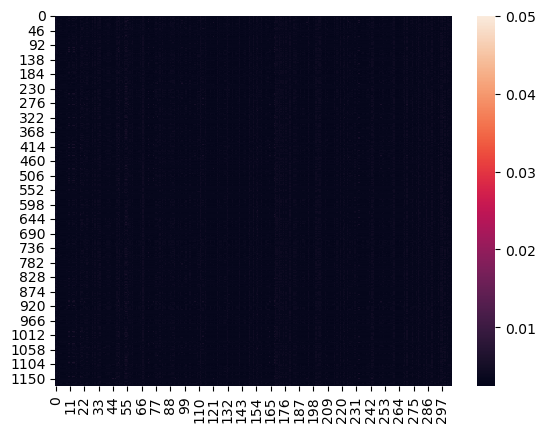

In [119]:
sns.heatmap(out.values['attn_s2z'].squeeze(), vmax=0.05)

<Axes: >

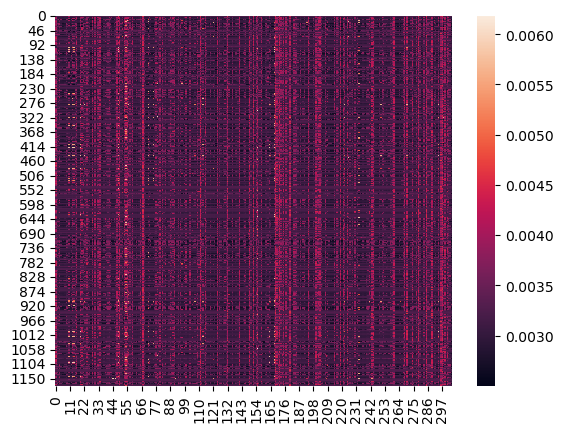

In [130]:
sns.heatmap(out.values['attn_s2z'].squeeze())

<Axes: >

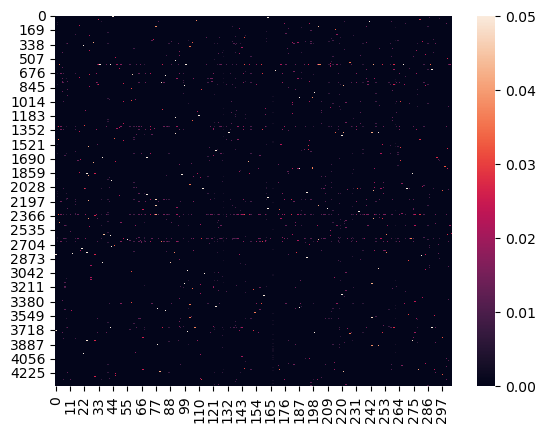

In [120]:
sns.heatmap(out.values['attn_n2s'].mean(axis=0), vmax=0.05)

---

In [121]:
attn = out.values['attn_s2z'].squeeze()
labels = data.y.detach().cpu().numpy()

# unique class IDs
classes = np.unique(labels)

# split per class into dictionary
class_to_attn = {c: attn[labels == c] for c in classes}

# Example: class 0's attention scores
print(class_to_attn[0].shape)  # (num_samples_in_class0, num_pathways)


(197, 305)


In [122]:
pathway_attn = pd.DataFrame(
    {
        'label':data.pathway_labels, 
        'global':attn.mean(axis=0),
        'basal':class_to_attn[0].mean(axis=0),
        'her2':class_to_attn[1].mean(axis=0),
        'lumA':class_to_attn[2].mean(axis=0),
        'lumB':class_to_attn[3].mean(axis=0),
        'norm':class_to_attn[4].mean(axis=0),
    }
)

pathway_attn = pathway_attn.sort_values(by='global', ascending=False)

pathway_attn

,label,global,basal,her2,lumA,lumB,norm
169,path:hsa00040,0.003995,0.003849,0.003888,0.004078,0.003994,0.003911
111,path:hsa04080,0.003961,0.003862,0.003911,0.004068,0.003989,0.003578
297,path:hsa00140,0.003955,0.003857,0.003942,0.004059,0.004006,0.003514
67,path:hsa00980,0.003951,0.003807,0.003938,0.004079,0.003976,0.003516
285,path:hsa00350,0.003926,0.003700,0.004027,0.004065,0.003935,0.003528
...,...,...,...,...,...,...,...
160,path:hsa00970,0.003002,0.002924,0.002940,0.003026,0.002912,0.003228
36,path:hsa04122,0.003002,0.002913,0.002935,0.003028,0.002916,0.003229
220,path:hsa03250,0.003001,0.002916,0.002932,0.003027,0.002915,0.003227
123,path:hsa04136,0.003001,0.002912,0.002922,0.003028,0.002920,0.003226


<Axes: ylabel='label'>

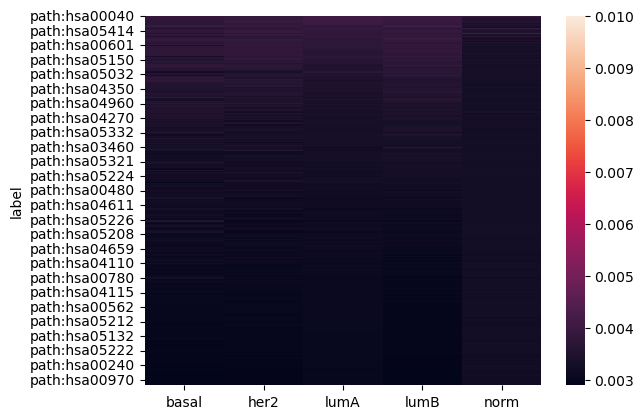

In [123]:
sns.heatmap(pathway_attn.drop(columns=['global']).set_index('label'), vmax=0.01)

<Axes: xlabel='global', ylabel='Count'>

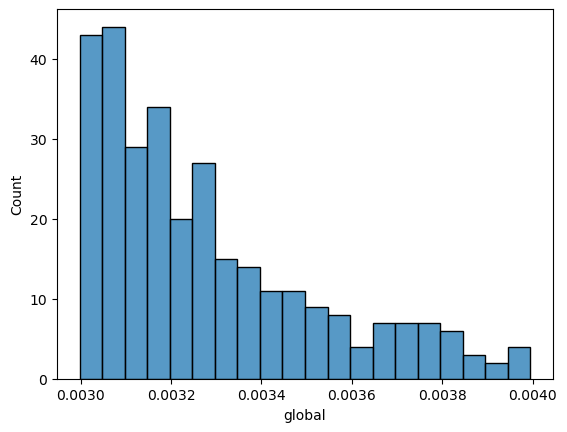

In [124]:
# sns.kdeplot(pathway_attn['global'])
sns.histplot(pathway_attn['global'], bins=20)

---

In [125]:
attn = out.values['attn_s2z'].squeeze()
labels = data.y.detach().cpu().numpy()

# unique class IDs
classes = np.unique(labels)

# split per class into dictionary
class_to_attn = {c: attn[labels == c] for c in classes}

# Example: class 0's attention scores
print(class_to_attn[0].shape)  # (num_samples_in_class0, num_pathways)


(197, 305)


In [126]:
n2s = out.values['attn_n2s']

labels = data.y.detach().cpu().numpy()
classes = np.unique(labels)

class_n2s = {c: n2s[labels == c] for c in classes}

In [127]:
node_attn = pd.DataFrame({
    'labels':data.x_labels,
    'global':n2s.mean(0).mean(-1),
    'basal':class_n2s[0].mean(0).mean(-1),
    'her2':class_n2s[1].mean(0).mean(-1),
    'lumA':class_n2s[2].mean(0).mean(-1),
    'lumB':class_n2s[3].mean(0).mean(-1),
    'norm':class_n2s[4].mean(0).mean(-1),
})

# node_attn = pd.DataFrame({
#     'labels':data.x_labels,
#     'global':n2s.mean(0).sum(-1),
#     'basal':class_n2s[0].mean(0).sum(-1),
#     'her2':class_n2s[1].mean(0).sum(-1),
#     'lumA':class_n2s[2].mean(0).sum(-1),
#     'lumB':class_n2s[3].mean(0).sum(-1),
#     'norm':class_n2s[4].mean(0).sum(-1),
# })

node_attn = node_attn.sort_values(by='global', ascending=False)

node_attn

,labels,global,basal,her2,lumA,lumB,norm
686,MAPK1,0.004697,0.004694,0.004686,0.004697,0.004688,0.004722
835,MAPK3,0.004694,0.004698,0.004680,0.004693,0.004684,0.004724
1361,AKT3,0.004690,0.004659,0.004711,0.004698,0.004725,0.004626
918,AKT2,0.004602,0.004600,0.004627,0.004598,0.004592,0.004625
2213,AKT1,0.004564,0.004574,0.004538,0.004556,0.004560,0.004614
...,...,...,...,...,...,...,...
3015,ZNF3,0.000007,0.000007,0.000007,0.000007,0.000007,0.000008
2798,SRSF2,0.000007,0.000007,0.000007,0.000007,0.000007,0.000008
1303,SRSF7,0.000007,0.000007,0.000007,0.000007,0.000007,0.000008
1166,SRSF3,0.000007,0.000007,0.000007,0.000007,0.000007,0.000008


<Axes: ylabel='labels'>

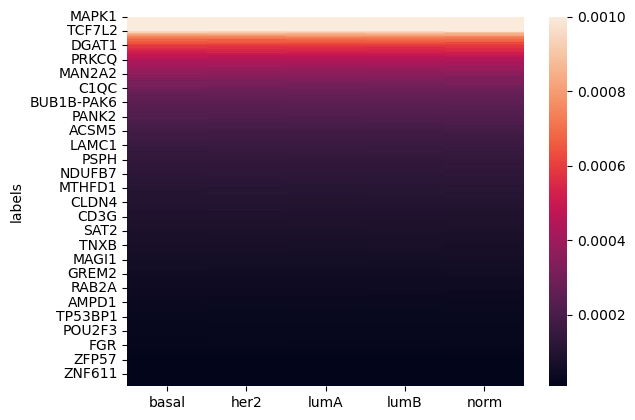

In [128]:
sns.heatmap(node_attn.drop(columns=['global']).set_index('labels'), vmax=0.001)

<Axes: xlabel='global', ylabel='Count'>

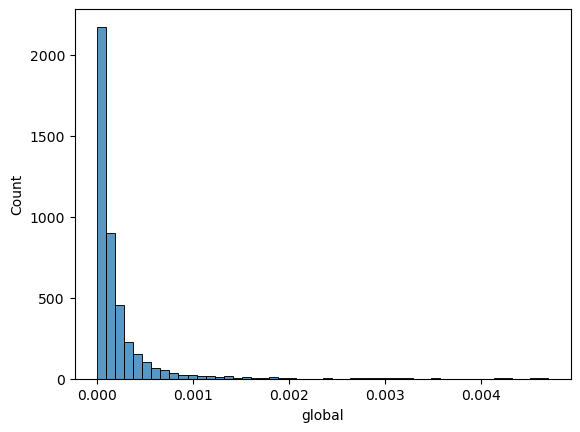

In [129]:
# sns.kdeplot(node_attn['global'])
sns.histplot(node_attn['global'], bins=50)